# Data Quality Checks

Quick QC before trusting a chunk's results:
- Does the RF mosaic look like a real, well-separated set of cells (not noise)?
- Does each cell type's RF time course look clean (biphasic, not flat/noisy)?
- Are cells actually responding during the noise stimulus (spike counts)?
- Does each cell's EI footprint look like the *same* cell when matched across light
  levels (NDFs) -- not just that `cluster_match()`'s correlation cleared a threshold?

Sets up its own experiment/pipeline the same way `1_database_demo.ipynb` does, so
this notebook runs standalone on one already-chosen experiment.


Import `retinanalysis` and the standard scientific-Python packages this notebook uses.

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Optional diagnostic: uncomment to debug a raw experiment file that fails to ingest into the database.

In [ ]:
# %run _diagnose_meta_json.py


Populate the DataJoint database from raw experiment files; only ingests experiments not already in the database unless `refresh_existing=True`.

In [3]:
ra.populate_database(refresh_existing=False)

[2026-08-10 16:55:30] DataJoint 2.2.2 connected to root@127.0.0.1:3306
Need to convert B:\Array-data\h5\20240326C.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250121C.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250403A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250418A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250906A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250911A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20250917A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251029A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251030A.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\20251030B.h5 to json
going to implement this eventually
Need to convert B:\Array-data\h5\202511

Experiments:   0%|          | 0/38 [00:00<?, ?it/s]

Already in database: 20240820A
Already in database: 20241120A
Already in database: 20250409A
Already in database: 20250417A
Already in database: 20250421A
Already in database: 20250421B
Already in database: 20250423A
Already in database: 20250909A
Already in database: 20250910A
Already in database: 20250912A
Already in database: 20250918A
Already in database: 20250926A
Already in database: 20251002A
Already in database: 20251004A
Already in database: 20251007A
Already in database: 20251008A
Already in database: 20251009A
Already in database: 20251014A
Already in database: 20251015A
Already in database: 20251016A
Already in database: 20251021A
Already in database: 20251022A
Already in database: 20251024A
Already in database: 20251031A
Already in database: 20251112A
Already in database: 20251211A
Already in database: 20251222A
Already in database: 20260224A
Already in database: 20260226A
Already in database: 20260227A
Already in database: 20260422A
Already in database: 20260501A
Already 

0

## Search for datasets

Searches the database for every SpatialNoise-protocol dataset, then filters to experiments that actually have local analysis files available on this machine.

In [4]:
exp_search = ra.get_datasets_from_protocol_names('spatialnoise')
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)
ra.scrollable_dataframe(exp_search)


Found 2 protocols matching "spatialnoise":
['fieldlab.protocols.SpatialNoise_ks' 'manookinlab.protocols.SpatialNoise']
No epochs found for block 3559

Found 31 experiments, 156 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20251009A,data002,5.0,data002,manookinlab.protocols.SpatialNoise,1,20251009A\data002,NDF 5,302,1,1056,3144,2702
1,20251009A,data005,4.0,data005,manookinlab.protocols.SpatialNoise,1,20251009A\data005,NDF 4,302,1,1057,3147,2706
2,20251009A,data008,3.0,data008,manookinlab.protocols.SpatialNoise,1,20251009A\data008,NDF 3,302,1,1058,3150,2710
3,20251009A,data012,2.0,data012,manookinlab.protocols.SpatialNoise,1,20251009A\data012,NDF 2,302,1,1059,3154,2715
4,20251009A,data015,1.0,data015,manookinlab.protocols.SpatialNoise,1,20251009A\data015,NDF 1,302,1,1060,3157,2719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,20250409A,data001,NaN,data001,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data001,Control,338,3,1206,3578,3155
152,20250409A,data002,NaN,data002,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data002,Control,338,3,1206,3579,3156
153,20250409A,data003,NaN,data003,fieldlab.protocols.SpatialNoise_ks,1,20250409A\data003,Control,338,3,1206,3580,3157
154,20250421A,data002,NaN,data002,fieldlab.protocols.SpatialNoise_ks,1,20250421A\data002,checkerboard noise and Doves NDF 3,340,3,1208,3584,3161


## Cell types to check

`None` (default) auto-detects every cell type in this chunk's classification file; the RF/timecourse/spike-count cells below all use this. Set to a specific list (e.g. `['on/brisk sustained']`) to restrict the QC checks instead.

In [16]:
cell_types = None  # e.g. ['on/brisk sustained'] to restrict -- None plots every type present


## Choose an Experiment

Pick which experiment to analyze and its SpatialNoise datafile (auto-picks the earliest if there are several).

In [ ]:
exp_name = '20260506A'
datafile_name = ra.find_datafile_for_protocol(exp_search, exp_name)

experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary.head())


## Initialize Analysis Pipeline

Builds the MEA pipeline for this datafile, auto-picking a classified white-noise chunk for cell typing unless you set `MANUAL_ANALYSIS_CHUNK`.

In [ ]:
PREFERRED_TYPING_FILE = None  # e.g. 'data007.classificationYT.txt' -- None auto-picks the first one found
MANUAL_ANALYSIS_CHUNK = None  # e.g. 'data001' -- set to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)

with ra.scrollable_prints():
    pipeline = ra.create_mea_pipeline(
        exp_name, datafile_name, analysis_chunk_name=analysis_chunk_name, typing_file=PREFERRED_TYPING_FILE,
    )


## Break Out Underlying Objects

Splits the pipeline into its stimulus, response, and analysis-chunk objects for direct use below.

In [19]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## Show Stim Information

Looks at the raw per-epoch stimulus table and pulls out block-level parameters -- including the space-constant/stixel-size values, which this dataset stores as `stixelSizes` rather than `spaceConstants`.

In [ ]:
stimulus_data = stim_block.df_epochs
display(stimulus_data)

epoch_block_params = stim_block.d_epoch_block_params
all_space_constants = epoch_block_params['stixelSizes']
space_constant = stimulus_data['epoch_parameters'].apply(
    lambda x: x['stixelSize']
).values


Peek at the raw `epoch_parameters` dict for the first epoch, to see exactly what fields are available.

In [ ]:
stimulus_data['epoch_parameters'].iloc[0]


## Pull Spike Times and Spike Counts

Extracts per-cell spike times/counts for the chosen cell types, plus a baseline (pre-stimulus) spike count for comparison.

In [ ]:
spike_times = ra.get_spike_xarr(response_block, cell_types = cell_types, minimum_n = 3)
spike_counts = xr.apply_ufunc(len, spike_times, vectorize = True)

def get_avg_baseline(arr, pre_time):
    pre_spikes = [spike for spike in arr if spike < pre_time]
    return len(pre_spikes)

pre_time = epoch_block_params['preTime']
baseline_spike_counts = xr.apply_ufunc(get_avg_baseline, spike_times,
                                       kwargs = {'pre_time' : pre_time},
                                       vectorize = True)


## Plot Noise RFs and Cluster Matched RFs to Compare

First, a quick count of cells per classification label; then each cell type's RF mosaic from both the protocol's own sort and the reference noise chunk, for comparison.

In [23]:
pipeline.analysis_chunk.df_cell_params['typing_file_0'].value_counts()

typing_file_0
Unknown                285
off/brisk sustained     25
on/brisk sustained      22
on/brisk transient      11
off/brisk transient     10
Name: count, dtype: int64

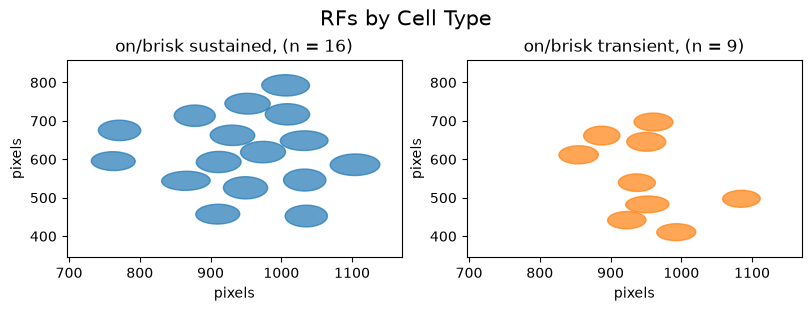

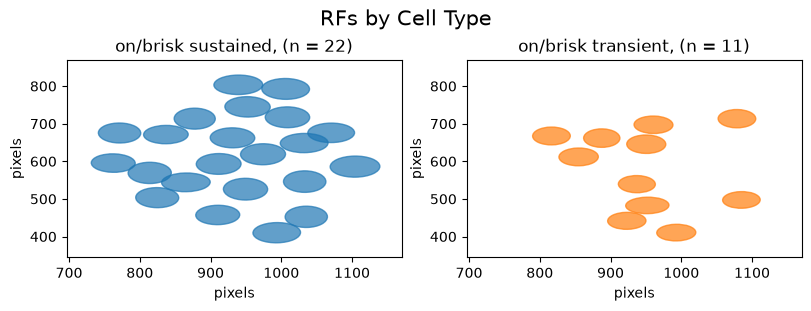

In [24]:
protocol_rfs = pipeline.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True)
noise_rfs = pipeline.analysis_chunk.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True,
                                             typing_file = PREFERRED_TYPING_FILE)


## Receptive Field Time Courses

Mean +/- SD time course per cell type (red/green/blue, from each cell's STA), same
cell-type/minimum_n filtering as the RF mosaic above. A cell type with a noisy,
non-biphasic, or flat time course here is a red flag even if its RF mosaic above
looked fine spatially -- these two checks catch different failure modes.


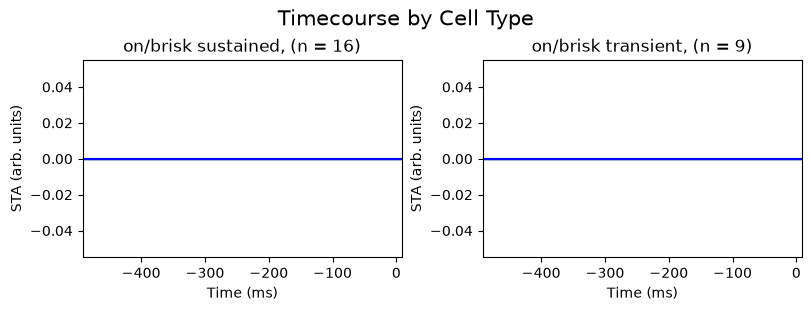

In [27]:
noise_timecourses = pipeline.plot_timecourses(cell_types = cell_types, minimum_n = 3)


## Spike Count Summary (quick QC check that cells are responding)

Per-cell-type spike count summary for this block -- a quick sanity check that cells
are actually firing during the noise stimulus, before trusting anything downstream.


In [ ]:
cell_types = sorted(np.unique(spike_times.coords['cell_type'].values))

means = []
sems = []
for ct in cell_types:
    ct_counts = spike_counts.where(spike_counts.cell_type == ct, drop = True)
    ct_baseline = baseline_spike_counts.where(baseline_spike_counts.cell_type == ct, drop = True)
    baseline_mean = ct_baseline.mean(dim = ['cell_id', 'epoch'], skipna = True).item()
    per_cell_mean = ct_counts.mean(dim = 'epoch', skipna = True) - baseline_mean
    n_cells = int(per_cell_mean.count(dim = 'cell_id'))
    means.append(per_cell_mean.mean(dim = 'cell_id', skipna = True).item())
    sems.append(per_cell_mean.std(dim = 'cell_id', skipna = True).item() / np.sqrt(max(n_cells, 1)))

fig, ax = plt.subplots()
x = np.arange(len(cell_types))
ax.bar(x, means, yerr = sems, capsize = 4, color = [f'C{i}' for i in range(len(cell_types))])
ax.axhline(0, color = 'k', linewidth = 0.8)
ax.set_xticks(x)
ax.set_xticklabels(cell_types, rotation = 30, ha = 'right')
ax.set_title(f'Spike Count by Cell Type ({exp_name} {datafile_name})')
ax.set_ylabel('Avg spike count (baseline-subtracted)')
ax.grid(True, axis = 'y')
fig.tight_layout()


---
## Data Quality: EI Footprint Across Light Levels

Checks that the reference chunk's cells track consistently across NDFs -- for one example cell, shows its EI footprint at the reference chunk plus its EI-matched counterpart at every other NDF this protocol was run at. Uses the existing `cluster_match()`/`ei_corr()` matching convention.


In [15]:
CELL_ID_TO_CHECK = None  # set to a specific cell_id in analysis_chunk.cell_ids to check that cell instead of auto-picking one

df_ei_matches, ndf_vcds, ref_ndf = ra.get_ei_matches_across_ndfs(
    analysis_chunk, exp_name, analysis_chunk.noise_protocol, ss_version=analysis_chunk.ss_version,
)

if len(df_ei_matches) == 0:
    print('No EI matches found against any other NDF for this protocol -- nothing to check.')
else:
    ei_match_summary = ra.summarize_ei_matches(df_ei_matches)
    print(f'{len(ei_match_summary)} ref cell(s) matched at >=1 other NDF (of {len(ndf_vcds)} other NDF(s) found). '
          f'Reference chunk ({analysis_chunk.chunk_name}) is at NDF {ref_ndf}.')
    print('Ranked best-to-worst -- pick a ref_cell_id from the table below, set CELL_ID_TO_CHECK to it, '
          'then just re-run the next cell (no need to re-run this one).')
    display(ei_match_summary.head(20))

20260506A: 5 'manookinlab.protocols.SpatialNoise' blocks found at NDF 0.0: ['data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data006.
20260506A: 2 'manookinlab.protocols.SpatialNoise' blocks found at NDF 3.0: ['data003', 'data004']. Using the earliest, data003.
20260506A: 2 'manookinlab.protocols.SpatialNoise' blocks found at NDF 4.0: ['data000', 'data001']. Using the earliest, data000.
20260506A: found 3 NDF level(s) for 'manookinlab.protocols.SpatialNoise': [0.0, 3.0, 4.0]
--- NDF 0.0 (data006) is the reference chunk's own datafile, skipping (matching it against itself is trivial) ---
--- NDF 3.0 (data003) ---
Initializing ResponseBlock for 20260506A block 3410
Keeping only 9 epochs.
Assuming n_epochs = 9
Loading VCD from B:\Array-data\sorted\20260506A\kilosort25\data003 ...
VCD loaded with 357 cells.

Cluster matching 20260506A data006 with SpatialNoise ...
67.71% matched, 32.29% unmatched.

--- NDF 4.0 (data000) ---
Initializing ResponseBlock for 20260506

,ref_cell_id,n_ndfs_matched,mean_corr,min_corr
0,117,2,0.999798,0.999736
1,14,2,0.999381,0.999091
2,93,2,0.999315,0.999052
3,414,2,0.999301,0.999207
4,108,2,0.999119,0.998620
5,150,2,0.998751,0.998131
6,80,2,0.998702,0.998477
7,380,2,0.998686,0.998500
8,90,2,0.998628,0.998454
9,449,2,0.998626,0.998208


### EI footprint mosaic: one cell type across NDFs, scrollable

Same footprint-across-NDFs comparison as the cell above, but one row per cell of a chosen type instead of a single cell, so a whole type can be scanned for outliers. Reuses `df_ei_matches`/`ndf_vcds` already computed above -- no re-matching.

In [ ]:
EI_MOSAIC_NDF_VALUES = None  # e.g. [5.0, 4.0] -- None uses every NDF in ndf_vcds (printed below)
EI_MOSAIC_CELL_TYPE = None  # e.g. 'off/brisk transient' -- None picks the first real (non-Unknown/Unmatched) type

if not ndf_vcds:
    print('No NDF data loaded (see the cell above) -- nothing to make a mosaic of.')
else:
    _typing_file_mosaic = next(
        (f for f in analysis_chunk.typing_files if 'classification' in f.lower()),
        analysis_chunk.typing_files[0],
    )
    _col_idx_mosaic = analysis_chunk.typing_files.index(_typing_file_mosaic)
    _available_types_mosaic = sorted(analysis_chunk.df_cell_params[f'typing_file_{_col_idx_mosaic}'].unique())
    _real_types_mosaic = [t for t in _available_types_mosaic if t not in ('Unknown', 'Unmatched')]
    ei_mosaic_cell_type = EI_MOSAIC_CELL_TYPE or (_real_types_mosaic[0] if _real_types_mosaic else _available_types_mosaic[0])
    print(f'EI footprint mosaic: cell type {ei_mosaic_cell_type!r}, NDF(s) {EI_MOSAIC_NDF_VALUES or sorted(ndf_vcds.keys(), reverse=True)} '
          f'+ reference (NDF {ref_ndf}) (available NDFs: {sorted(ndf_vcds.keys())}; available types: {_available_types_mosaic})')

    fig_ei_mosaic = ra.plot_ei_footprint_mosaic_for_cell_type(
        analysis_chunk, df_ei_matches, ndf_vcds, ei_mosaic_cell_type,
        ndf_values=EI_MOSAIC_NDF_VALUES, ref_ndf=ref_ndf, typing_file=_typing_file_mosaic,
    )
    ra.scrollable_figure(fig_ei_mosaic, max_height_px=600)
